# 17_E9 - Baseline axial T2 Al-Kafri final labels

Notebook simple y seguro: usa solo modalidad T2 y los labels finales `L1_XXXX_DY.png` generados en el notebook `16_E8_alkafri_FINAL_LABELS_FIXED_3.ipynb`.

Si faltan paquetes en Colab, ejecutar antes: `%pip install pydicom scikit-image`.


In [2]:
%pip install pydicom scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.4 MB/s eta 0:00:00


In [3]:
import json, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pydicom
from PIL import Image
from scipy import ndimage
from skimage.transform import resize
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
PFI_ROOT=Path('/content/drive/MyDrive/PFI_MVP')
E8_ROOT=PFI_ROOT/'results'/'E8_alkafri_official_pairing'
E9_ROOT=PFI_ROOT/'results'/'E9_alkafri_axial_t2_final_labels_baseline'
FIGURES_ROOT=PFI_ROOT/'figures'; MODELS_ROOT=PFI_ROOT/'models'; DOCS_ROOT=PFI_ROOT/'docs'
for p in [E9_ROOT,FIGURES_ROOT,MODELS_ROOT,DOCS_ROOT]: p.mkdir(parents=True, exist_ok=True)
CAND_PATH=E8_ROOT/'E8_FINAL_LABELS_FIXED_3_candidates.csv'
assert CAND_PATH.exists(), 'Ejecutar primero 16_E8_alkafri_FINAL_LABELS_FIXED_3.ipynb'
IMG_SIZE=256; NUM_CLASSES=6; BATCH_SIZE=8; EPOCHS=20; LR=1e-3; BASE=16
RAW_VALUES=np.array([0,50,100,150,200,250], dtype=np.int16)
RAW_TO_CLASS={250:0,0:1,50:2,100:3,150:4,200:5}
CLASS_NAMES={0:'background_250',1:'raw_0',2:'raw_50',3:'raw_100',4:'raw_150',5:'raw_200'}
print('CAND_PATH:', CAND_PATH)
print('cuda:', torch.cuda.is_available())


Mounted at /content/drive
CAND_PATH: /content/drive/MyDrive/PFI_MVP/results/E8_alkafri_official_pairing/E8_FINAL_LABELS_FIXED_3_candidates.csv
cuda: False


In [5]:
def read_img(path):
    return pydicom.dcmread(str(path), force=True).pixel_array.astype(np.float32)

def norm_img(x):
    p1, p99 = np.percentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x, dtype=np.float32)
    return ((np.clip(x, p1, p99) - p1) / (p99 - p1 + 1e-8)).astype(np.float32)

def read_label(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = arr.astype(np.int16)
    flat = arr.reshape(-1)
    snapped = RAW_VALUES[
        np.abs(flat[:, None] - RAW_VALUES[None, :]).argmin(axis=1)
    ].reshape(arr.shape)

    out = np.zeros_like(snapped, dtype=np.uint8)
    for rv, cid in RAW_TO_CLASS.items():
        out[snapped == rv] = cid
    return out

def rimg(x):
    return resize(
        x.astype(np.float32),
        (IMG_SIZE, IMG_SIZE),
        order=1,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)

def rlbl(y):
    return resize(
        y.astype(np.float32),
        (IMG_SIZE, IMG_SIZE),
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    ).astype(np.uint8)

def ncomp(mask):
    return int(ndimage.label(mask.astype(bool))[1])

# Versión rápida: sanity sobre labels finales, sin leer todos los DICOMs.
# Los DICOMs ya fueron validados en E8 y se leerán durante el entrenamiento.
def sanity_fast(row):
    try:
        lbl = read_label(row.final_label_file_path)
        fg = lbl > 0
        vals = sorted([int(v) for v in np.unique(lbl)])
        ratio = float(fg.mean())
        cc = ncomp(fg)

        ok = (
            (0.005 <= ratio <= 0.20)
            and (cc <= 20)
            and (len(vals) >= 2)
            and Path(row.image_file_path).exists()
            and Path(row.final_label_file_path).exists()
        )

        return {
            "sanity_ok": ok,
            "image_shape": "not_read_fast_sanity",
            "label_shape": str(tuple(lbl.shape)),
            "label_values": json.dumps(vals),
            "foreground_ratio": ratio,
            "component_count": cc,
            "error": "",
        }

    except Exception as e:
        return {
            "sanity_ok": False,
            "image_shape": "",
            "label_shape": "",
            "label_values": "[]",
            "foreground_ratio": np.nan,
            "component_count": np.nan,
            "error": repr(e),
        }

df = pd.read_csv(CAND_PATH)

df = df[df.modality.astype(str).eq("T2")].copy()
df["case_id_norm"] = df.case_id_norm.astype(str).str.zfill(4)
df["disc_id"] = pd.to_numeric(df.disc_id, errors="coerce").astype(int)

df = df.drop_duplicates(
    ["case_id_norm", "disc_id", "image_file_path", "final_label_file_path"]
).reset_index(drop=True)

print("T2 candidatos:", df.shape)

san_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="sanity rápido labels T2"):
    san_rows.append(sanity_fast(row))

san = pd.DataFrame(san_rows)

df = pd.concat([df, san], axis=1)
df.to_csv(E9_ROOT / "E9_t2_final_labels_sanity.csv", index=False)

df = df[df.sanity_ok].copy().reset_index(drop=True)
df.to_csv(E9_ROOT / "E9_t2_final_labels_curated_candidates.csv", index=False)

print("T2 curated:", df.shape)

display(
    df[
        [
            "case_id_norm",
            "disc_id",
            "foreground_ratio",
            "component_count",
            "label_values",
        ]
    ].head()
)

display(df[["foreground_ratio", "component_count"]].describe())

assert len(df) >= 50, "Muy pocos pares curados."

cases = np.array(sorted(df.case_id_norm.unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(cases)

ntr = int(0.70 * len(cases))
nval = int(0.15 * len(cases))

train_cases = set(cases[:ntr])
val_cases = set(cases[ntr : ntr + nval])

def split(c):
    return "train" if c in train_cases else ("val" if c in val_cases else "test")

df["split"] = df.case_id_norm.apply(split)

df.to_csv(E9_ROOT / "E9_t2_final_labels_curated_split.csv", index=False)

display(
    df.groupby("split")
    .agg(n=("case_id_norm", "size"), cases=("case_id_norm", "nunique"))
    .reset_index()
)

T2 candidatos: (610, 15)


sanity rápido labels T2:   0%|          | 0/610 [00:00<?, ?it/s]

T2 curated: (610, 22)


,case_id_norm,disc_id,foreground_ratio,component_count,label_values
0,0001,3,0.055205,1,"[0, 2, 3, 4, 5]"
1,0001,4,0.071836,1,"[0, 2, 3, 4, 5]"
2,0001,5,0.059258,2,"[0, 2, 3, 4, 5]"
3,0002,3,0.062734,7,"[0, 1, 2, 3, 4, 5]"
4,0002,4,0.071309,3,"[0, 1, 2, 3, 4, 5]"


,foreground_ratio,component_count
count,610.000000,610.000000
mean,0.062184,2.047541
std,0.011485,1.802034
min,0.035742,1.000000
25%,0.055059,1.000000
50%,0.061333,1.000000
75%,0.067620,2.000000
max,0.139307,15.000000


,split,n,cases
0,test,102,29
1,train,427,128
2,val,81,27


In [6]:
class DS(Dataset):
    def __init__(self, frame): self.df=frame.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        x=rimg(norm_img(read_img(r.image_file_path)))
        y=rlbl(read_label(r.final_label_file_path))
        return torch.from_numpy(x[None]).float(), torch.from_numpy(y).long()
class DC(nn.Module):
    def __init__(self,a,b):
        super().__init__(); self.net=nn.Sequential(nn.Conv2d(a,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU(True),nn.Conv2d(b,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU(True))
    def forward(self,x): return self.net(x)
class UNet(nn.Module):
    def __init__(self):
        super().__init__(); b=BASE
        self.e1=DC(1,b); self.e2=DC(b,b*2); self.e3=DC(b*2,b*4); self.pool=nn.MaxPool2d(2); self.mid=DC(b*4,b*8)
        self.u3=nn.ConvTranspose2d(b*8,b*4,2,2); self.d3=DC(b*8,b*4)
        self.u2=nn.ConvTranspose2d(b*4,b*2,2,2); self.d2=DC(b*4,b*2)
        self.u1=nn.ConvTranspose2d(b*2,b,2,2); self.d1=DC(b*2,b); self.out=nn.Conv2d(b,NUM_CLASSES,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); m=self.mid(self.pool(e3))
        x=self.d3(torch.cat([self.u3(m),e3],1)); x=self.d2(torch.cat([self.u2(x),e2],1)); x=self.d1(torch.cat([self.u1(x),e1],1))
        return self.out(x)
def dice_loss(logits,y,eps=1e-6):
    p=torch.softmax(logits,1); oh=F.one_hot(y,NUM_CLASSES).permute(0,3,1,2).float(); dims=(0,2,3)
    inter=(p*oh).sum(dims); den=p.sum(dims)+oh.sum(dims); dice=(2*inter+eps)/(den+eps)
    return 1-dice[1:].mean()
def loss_fn(logits,y): return F.cross_entropy(logits,y)+dice_loss(logits,y)
@torch.no_grad()
def evaluate(loader):
    model.eval(); inter=torch.zeros(NUM_CLASSES,device=device); ps=torch.zeros(NUM_CLASSES,device=device); gs=torch.zeros(NUM_CLASSES,device=device); losses=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device); logits=model(x); losses.append(float(loss_fn(logits,y).cpu())); pred=logits.argmax(1)
        for c in range(NUM_CLASSES):
            p=pred==c; g=y==c; inter[c]+=(p&g).sum(); ps[c]+=p.sum(); gs[c]+=g.sum()
    dice=(2*inter)/(ps+gs+1e-7); iou=inter/(ps+gs-inter+1e-7); present=gs[1:]>0
    return {'loss':float(np.mean(losses)),'dice_macro_no_bg':float(dice[1:][present].mean().cpu()),'iou_macro_no_bg':float(iou[1:][present].mean().cpu()),'dice_by_class':{CLASS_NAMES[i]:float(dice[i].cpu()) for i in range(NUM_CLASSES)},'iou_by_class':{CLASS_NAMES[i]:float(iou[i].cpu()) for i in range(NUM_CLASSES)}}
train_df=df[df.split.eq('train')]; val_df=df[df.split.eq('val')]; test_df=df[df.split.eq('test')]
train_loader=DataLoader(DS(train_df),batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True)
val_loader=DataLoader(DS(val_df),batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
test_loader=DataLoader(DS(test_df),batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); model=UNet().to(device); opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
print('device:',device,'train/val/test:',len(train_df),len(val_df),len(test_df))


device: cpu train/val/test: 427 81 102


In [7]:
hist=[]; best=-1; best_state=None; best_path=MODELS_ROOT/'E9_axial_t2_final_labels_unet_best_state_dict.pt'
for ep in range(1,EPOCHS+1):
    model.train(); tr=[]
    for x,y in tqdm(train_loader,desc=f'epoch {ep:02d}/{EPOCHS}',leave=False):
        x=x.to(device); y=y.to(device); opt.zero_grad(set_to_none=True); loss=loss_fn(model(x),y); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tr.append(float(loss.cpu()))
    vm=evaluate(val_loader); row={'epoch':ep,'train_loss':float(np.mean(tr)),'val_loss':vm['loss'],'val_dice_macro_no_bg':vm['dice_macro_no_bg'],'val_iou_macro_no_bg':vm['iou_macro_no_bg']}
    hist.append(row); print(row)
    if vm['dice_macro_no_bg']>best:
        best=vm['dice_macro_no_bg']; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; torch.save(best_state,best_path); print('nuevo best:',best)
hist=pd.DataFrame(hist); hist.to_csv(E9_ROOT/'E9_training_history.csv',index=False); display(hist.tail())
plt.figure(figsize=(7,4)); plt.plot(hist.epoch,hist.train_loss,label='train'); plt.plot(hist.epoch,hist.val_loss,label='val'); plt.legend(); plt.grid(alpha=.3); plt.savefig(FIGURES_ROOT/'E9_axial_t2_training_loss.png',dpi=150,bbox_inches='tight'); plt.show()
plt.figure(figsize=(7,4)); plt.plot(hist.epoch,hist.val_dice_macro_no_bg,label='val dice'); plt.plot(hist.epoch,hist.val_iou_macro_no_bg,label='val IoU'); plt.legend(); plt.grid(alpha=.3); plt.savefig(FIGURES_ROOT/'E9_axial_t2_val_metrics.png',dpi=150,bbox_inches='tight'); plt.show()


epoch 01/20:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.1492427543357566, 'val_loss': 1.881297685883262, 'val_dice_macro_no_bg': 0.1445300430059433, 'val_iou_macro_no_bg': 0.09476729482412338}
nuevo best: 0.1445300430059433


epoch 02/20:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 1.4944608829639576, 'val_loss': 1.2442670301957564, 'val_dice_macro_no_bg': 0.4075326919555664, 'val_iou_macro_no_bg': 0.3211788237094879}
nuevo best: 0.4075326919555664


epoch 03/20:   0%|          | 0/54 [00:00<?, ?it/s]

...

epoch 09/20:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.4241700459409643, 'val_loss': 0.40923244844783435, 'val_dice_macro_no_bg': 0.6718534231185913, 'val_iou_macro_no_bg': 0.5880170464515686}


epoch 10/20:   0%|          | 0/54 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ccb588e0ae0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ccb588e0ae0>
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

KeyboardInterrupt: 

In [8]:
# FIX: recrear DataLoaders sin multiprocessing y cargar mejor modelo guardado

train_df = df[df.split.eq("train")].copy()
val_df = df[df.split.eq("val")].copy()
test_df = df[df.split.eq("test")].copy()

train_loader = DataLoader(
    DS(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    DS(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    DS(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

best_path = MODELS_ROOT / "E9_axial_t2_final_labels_unet_best_state_dict.pt"

if "best_state" in globals() and best_state is not None:
    print("Cargando best_state desde memoria")
    model.load_state_dict(best_state)
elif best_path.exists():
    print("Cargando best_state desde archivo:", best_path)
    model.load_state_dict(torch.load(best_path, map_location=device))
else:
    raise FileNotFoundError("No encontré best_state ni best_path.")

model = model.to(device)
print("OK loaders sin workers.")
print("train/val/test:", len(train_df), len(val_df), len(test_df))

Cargando best_state desde memoria
OK loaders sin workers.
train/val/test: 427 81 102


VAL:
{
  "loss": 0.4040889712897214,
  "dice_macro_no_bg": 0.6934610605239868,
  "iou_macro_no_bg": 0.6182933449745178,
  "dice_by_class": {
    "background_250": 0.9950613975524902,
    "raw_0": 0.0,
    "raw_50": 0.9607799649238586,
    "raw_100": 0.8970046043395996,
    "raw_150": 0.859728217124939,
    "raw_200": 0.7497925162315369
  },
  "iou_by_class": {
    "background_250": 0.9901712536811829,
    "raw_0": 0.0,
    "raw_50": 0.9245202541351318,
    "raw_100": 0.8132442235946655,
    "raw_150": 0.753967821598053,
    "raw_200": 0.5997344255447388
  }
}
TEST:
{
  "loss": 0.4748545541213109,
  "dice_macro_no_bg": 0.6401236057281494,
  "iou_macro_no_bg": 0.5421680212020874,
  "dice_by_class": {
    "background_250": 0.9929535984992981,
    "raw_0": 0.0,
    "raw_50": 0.9287970662117004,
    "raw_100": 0.8323450088500977,
    "raw_150": 0.778452455997467,
    "raw_200": 0.6610235571861267
  },
  "iou_by_class": {
    "background_250": 0.9860058426856995,
    "raw_0": 0.0,
    "raw_5

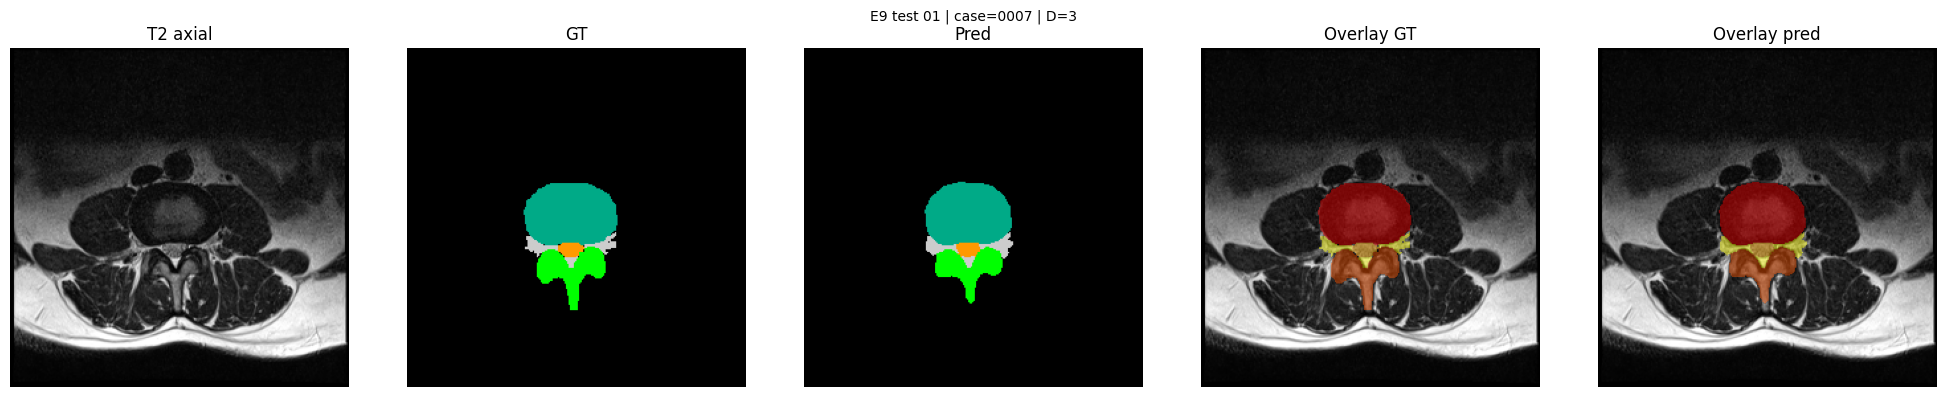

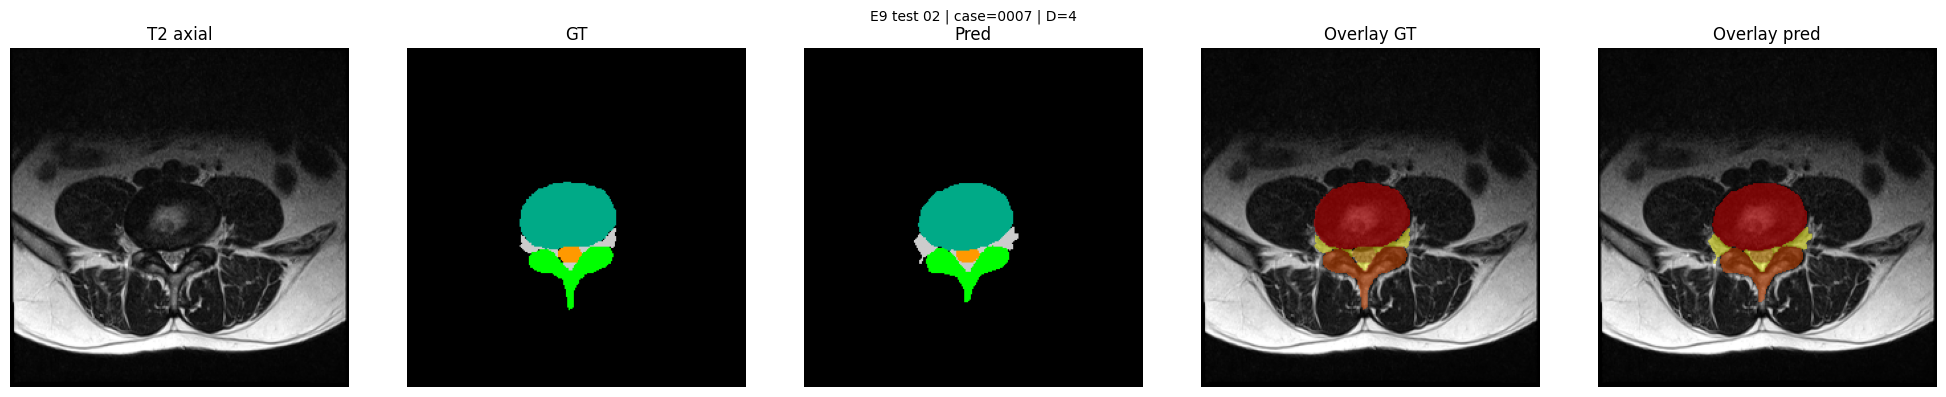

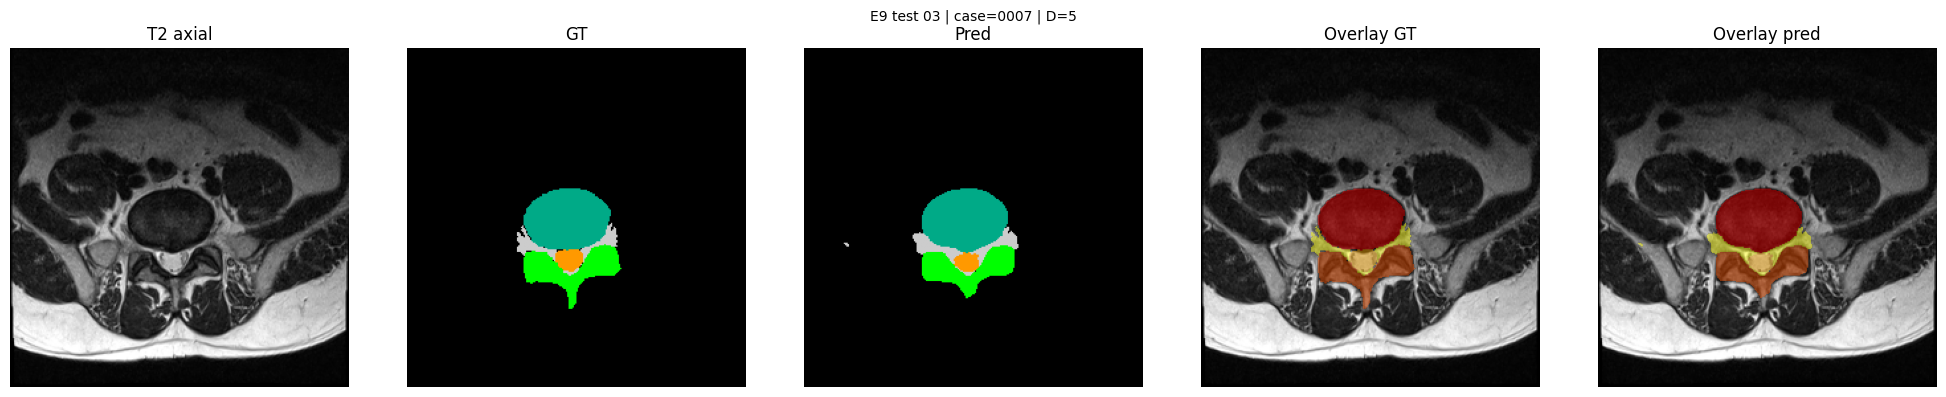

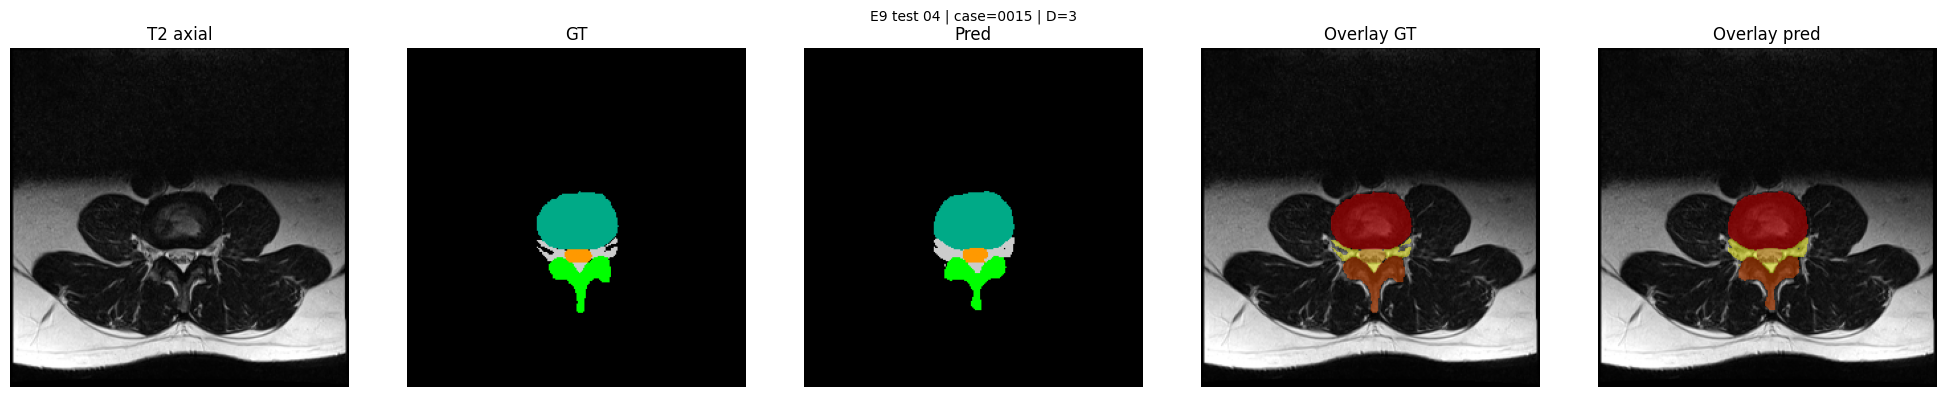

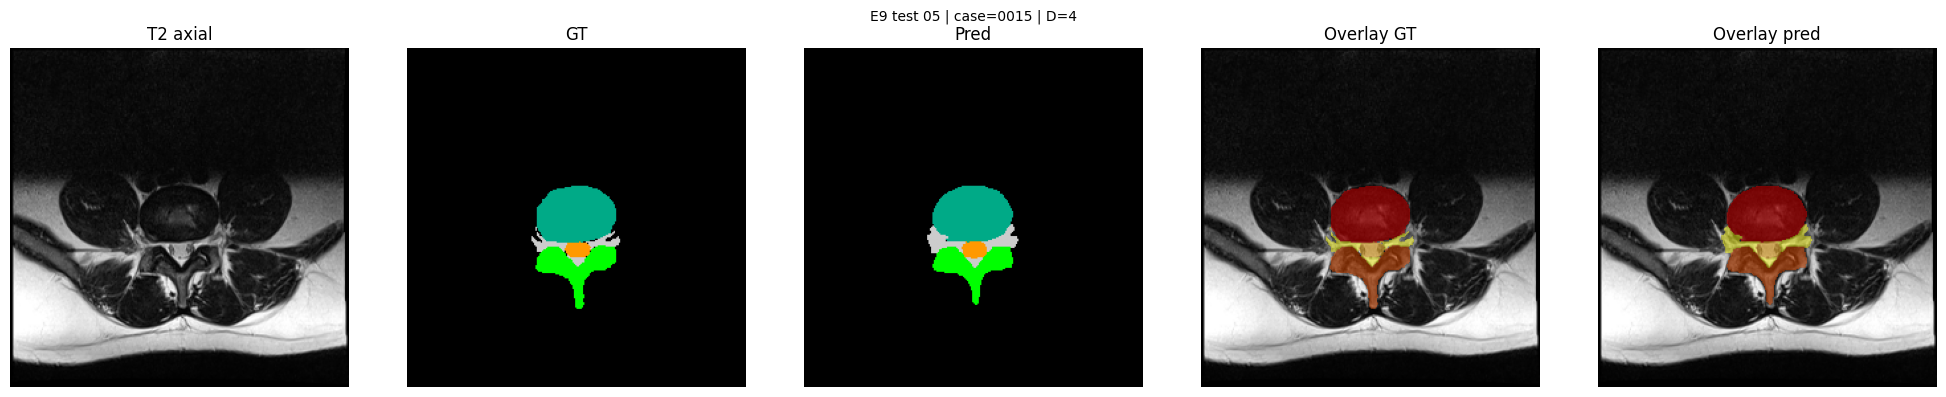

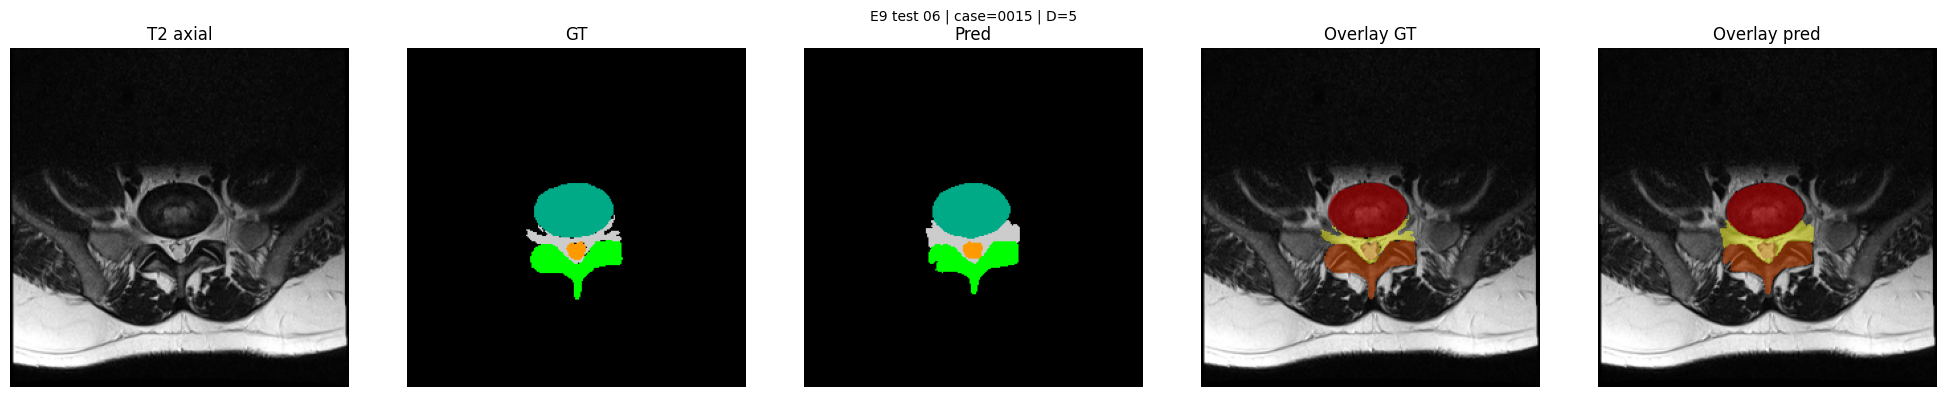

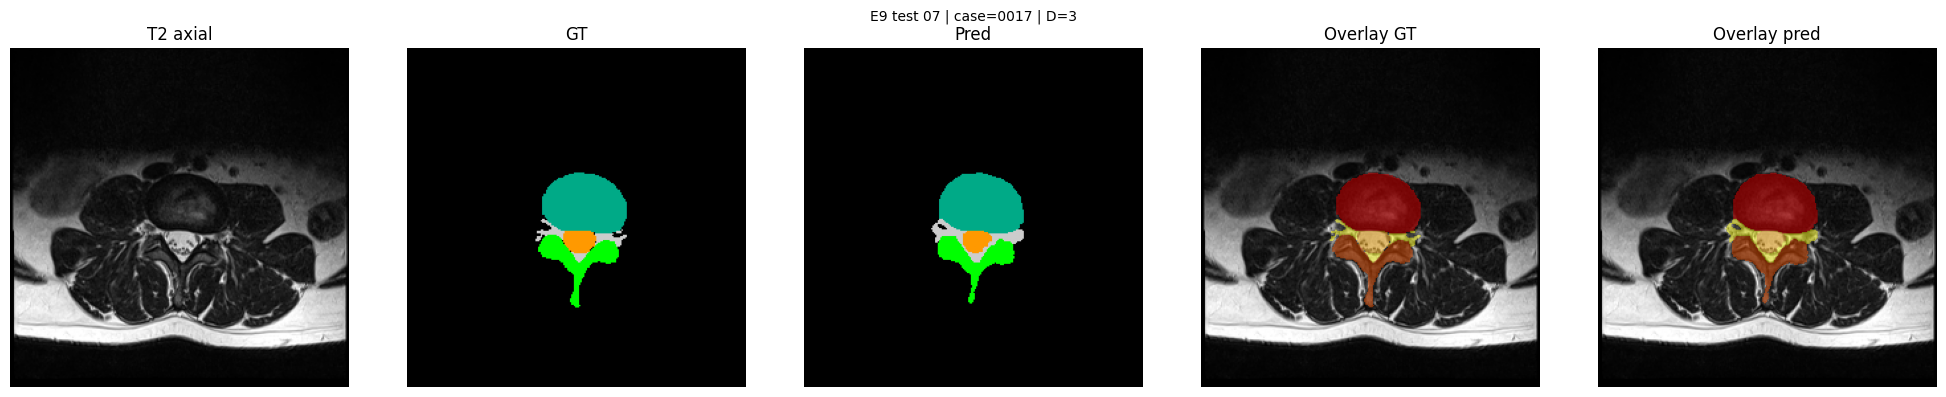

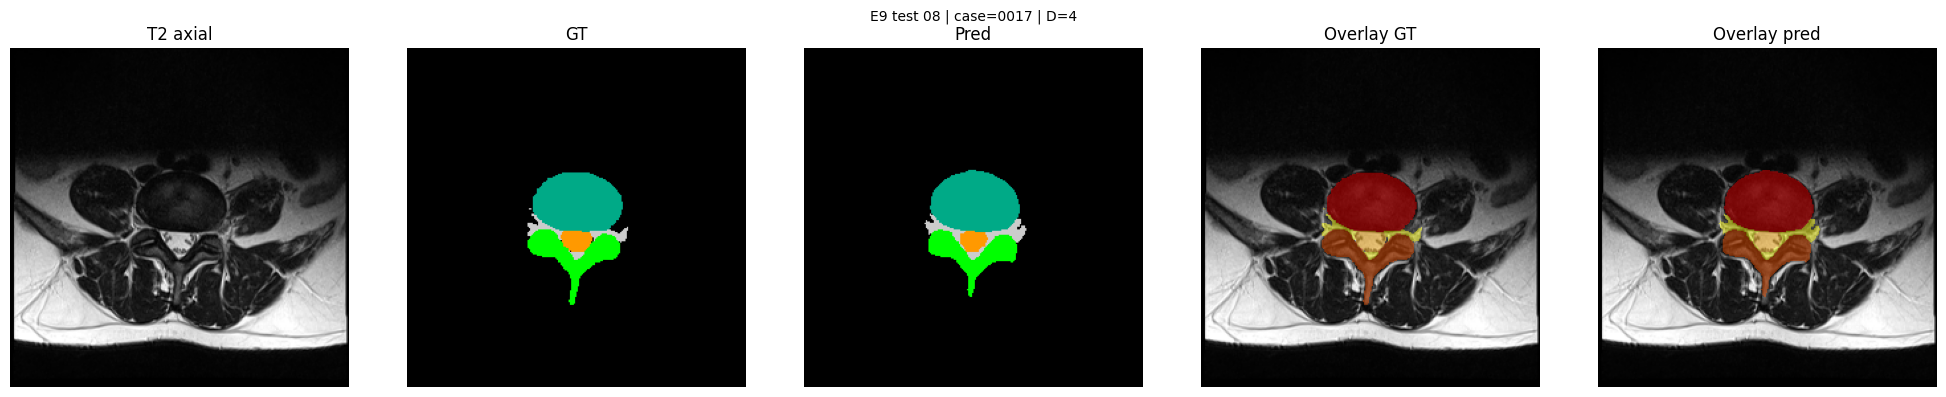

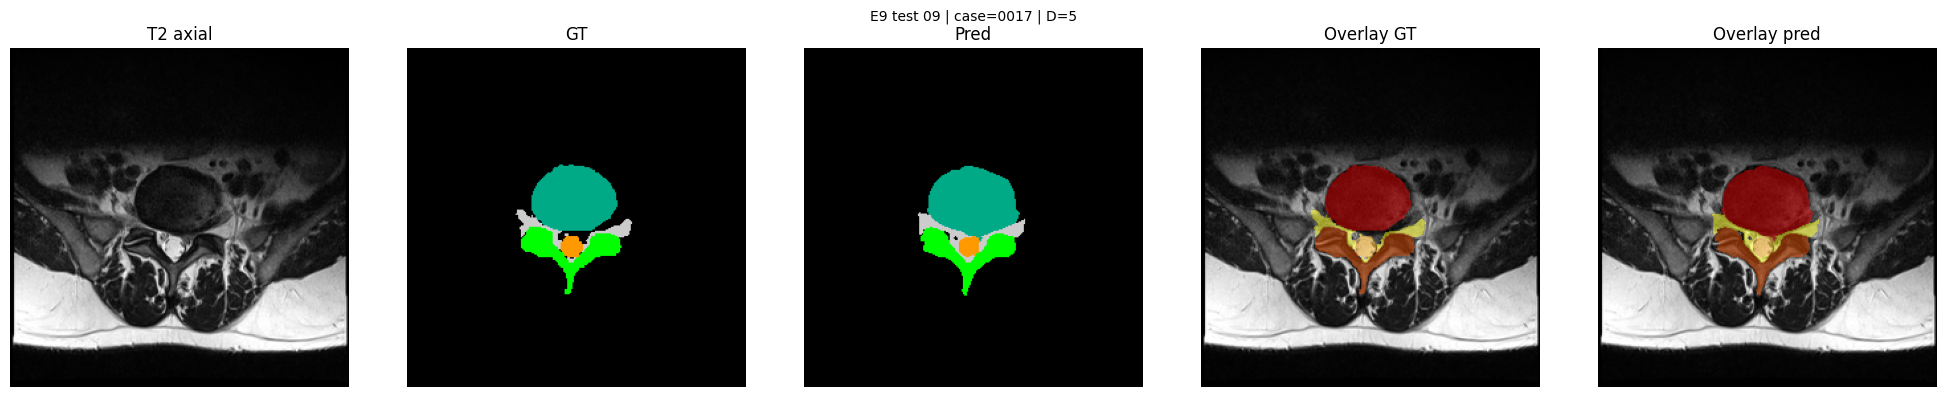

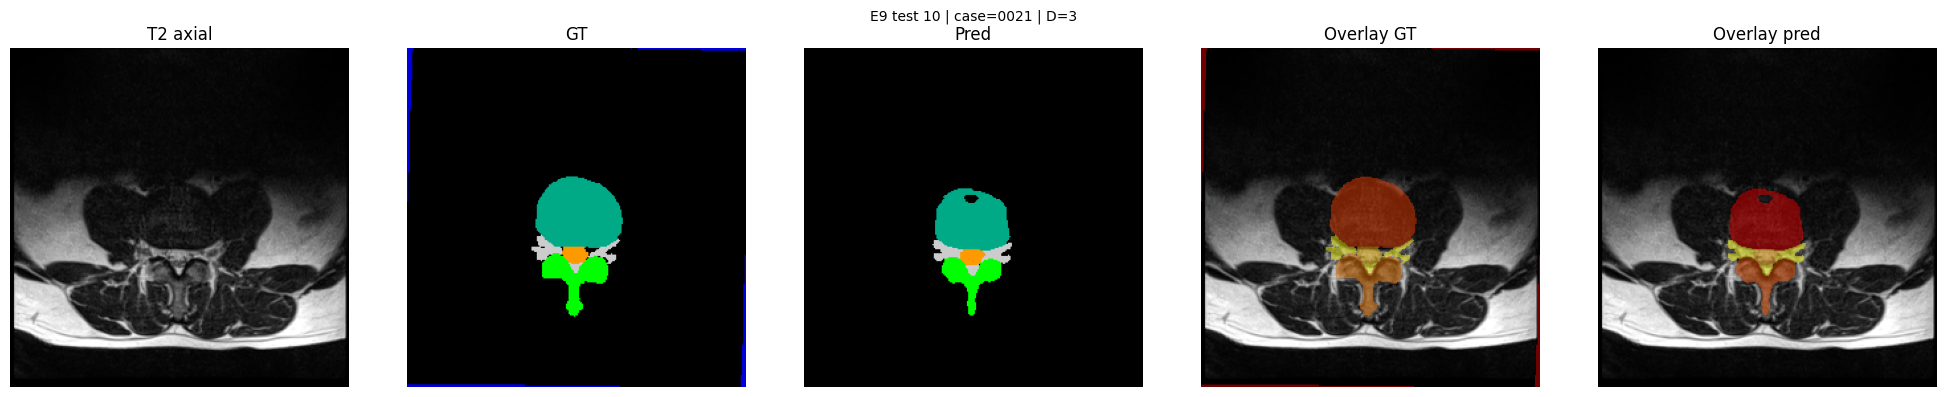

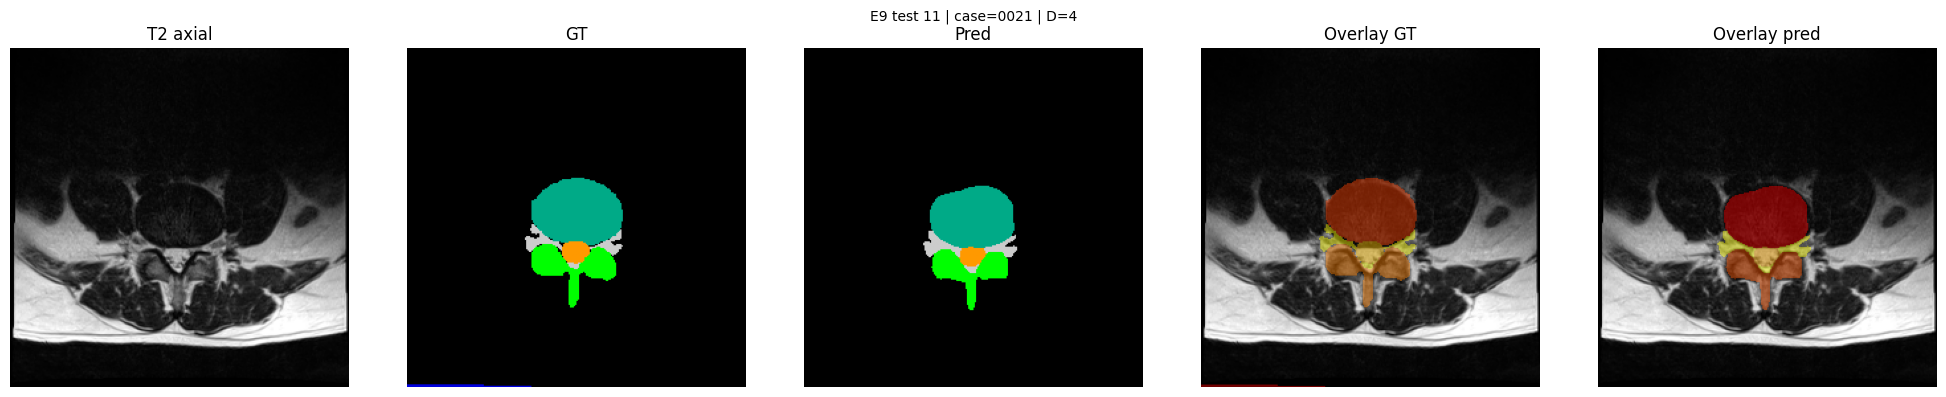

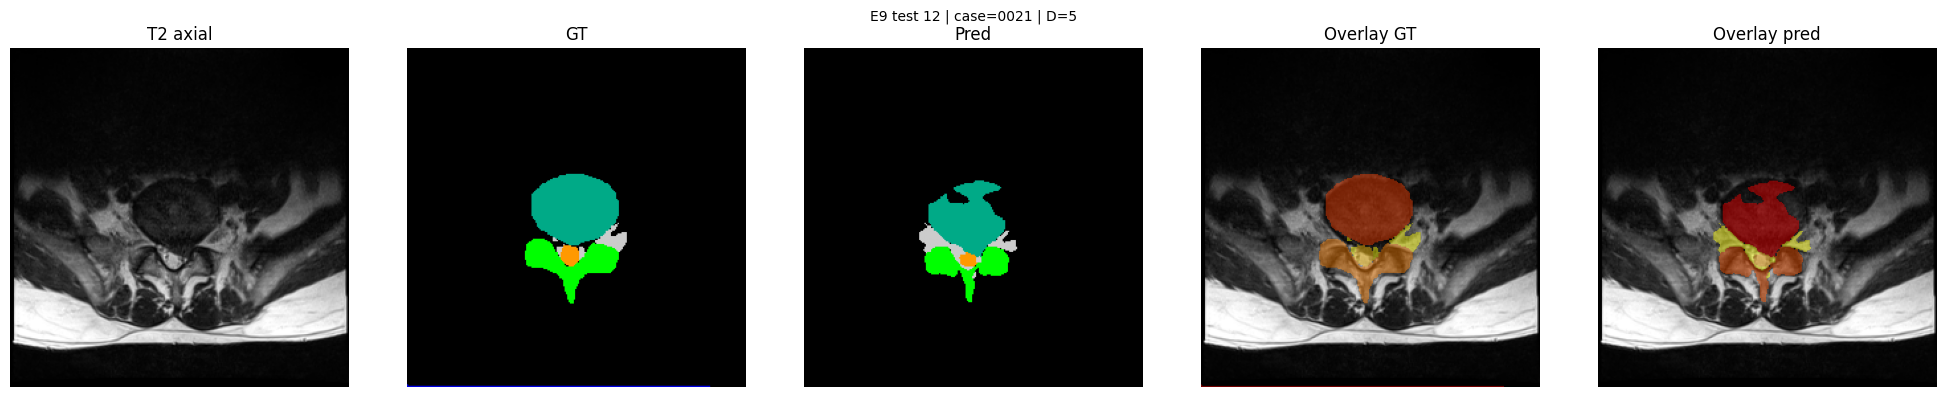

Reporte final: /content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_axial_t2_final_labels_baseline_report.json
{
  "notebook": "17_E9_alkafri_axial_t2_final_labels_baseline_simple",
  "strategy": "safe T2-only axial baseline using final L1 labels",
  "curated_candidates": 610,
  "split_counts": {
    "test": 102,
    "train": 427,
    "val": 81
  },
  "epochs_completed_before_stop": "at least 9",
  "best_model_path": "/content/drive/MyDrive/PFI_MVP/models/E9_axial_t2_final_labels_unet_best_state_dict.pt",
  "best_val_dice_macro_no_bg_seen": 0.6934610605239868,
  "val_metrics": {
    "loss": 0.4040889712897214,
    "dice_macro_no_bg": 0.6934610605239868,
    "iou_macro_no_bg": 0.6182933449745178,
    "dice_by_class": {
      "background_250": 0.9950613975524902,
      "raw_0": 0.0,
      "raw_50": 0.9607799649238586,
      "raw_100": 0.8970046043395996,
      "raw_150": 0.859728217124939,
      "raw_200": 0.7497925162315369
    },
    "iou_by_class": {
   

In [9]:
# Evaluación final usando el mejor checkpoint disponible

val_metrics = evaluate(val_loader)
test_metrics = evaluate(test_loader)

print("VAL:")
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

print("TEST:")
print(json.dumps(test_metrics, indent=2, ensure_ascii=False))

(E9_ROOT / "E9_val_metrics.json").write_text(
    json.dumps(val_metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

(E9_ROOT / "E9_test_metrics.json").write_text(
    json.dumps(test_metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

def predict(r):
    img = rimg(norm_img(read_img(r.image_file_path)))
    gt = rlbl(read_label(r.final_label_file_path))

    with torch.no_grad():
        pred = model(
            torch.from_numpy(img[None, None]).float().to(device)
        ).argmax(1)[0].cpu().numpy().astype(np.uint8)

    return img, gt, pred

fig_rows = []

for i, (_, r) in enumerate(
    test_df.sort_values(["case_id_norm", "disc_id"]).head(12).iterrows(),
    1,
):
    img, gt, pred = predict(r)

    fig, ax = plt.subplots(1, 5, figsize=(20, 4))

    ax[0].imshow(img, cmap="gray")
    ax[0].set_title("T2 axial")

    ax[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES - 1)
    ax[1].set_title("GT")

    ax[2].imshow(pred, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES - 1)
    ax[2].set_title("Pred")

    ax[3].imshow(img, cmap="gray")
    ax[3].imshow(np.ma.masked_where(gt <= 0, gt), cmap="autumn", alpha=0.45)
    ax[3].set_title("Overlay GT")

    ax[4].imshow(img, cmap="gray")
    ax[4].imshow(np.ma.masked_where(pred <= 0, pred), cmap="autumn", alpha=0.45)
    ax[4].set_title("Overlay pred")

    for a in ax:
        a.axis("off")

    fig.suptitle(
        f"E9 test {i:02d} | case={r.case_id_norm} | D={r.disc_id}",
        fontsize=10,
    )

    fig.tight_layout()

    fp = FIGURES_ROOT / f"E9_axial_t2_prediction_test_{i:02d}.png"
    fig.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()

    fig_rows.append(
        {
            "case_id_norm": r.case_id_norm,
            "disc_id": int(r.disc_id),
            "figure_path": str(fp),
        }
    )

pd.DataFrame(fig_rows).to_csv(
    E9_ROOT / "E9_prediction_figures.csv",
    index=False,
)

best_val = None
if "best" in globals():
    best_val = float(best)

report = {
    "notebook": "17_E9_alkafri_axial_t2_final_labels_baseline_simple",
    "strategy": "safe T2-only axial baseline using final L1 labels",
    "curated_candidates": int(len(df)),
    "split_counts": df.groupby("split").size().to_dict(),
    "epochs_completed_before_stop": "at least 9",
    "best_model_path": str(best_path),
    "best_val_dice_macro_no_bg_seen": best_val,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "decision": "baseline_completed_pending_interpretation",
}

rp = E9_ROOT / "E9_axial_t2_final_labels_baseline_report.json"

rp.write_text(
    json.dumps(report, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

(DOCS_ROOT / "E9_axial_t2_final_labels_baseline_conclusion.md").write_text(
    "# E9 axial T2 baseline\n\n"
    + json.dumps(report, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Reporte final:", rp)
print(json.dumps(report, indent=2, ensure_ascii=False))

In [ ]:
model.load_state_dict(best_state)
val_metrics=evaluate(val_loader); test_metrics=evaluate(test_loader)
print('VAL:',json.dumps(val_metrics,indent=2,ensure_ascii=False)); print('TEST:',json.dumps(test_metrics,indent=2,ensure_ascii=False))
(E9_ROOT/'E9_val_metrics.json').write_text(json.dumps(val_metrics,indent=2,ensure_ascii=False),encoding='utf-8')
(E9_ROOT/'E9_test_metrics.json').write_text(json.dumps(test_metrics,indent=2,ensure_ascii=False),encoding='utf-8')
def predict(r):
    img=rimg(norm_img(read_img(r.image_file_path))); gt=rlbl(read_label(r.final_label_file_path))
    with torch.no_grad(): pred=model(torch.from_numpy(img[None,None]).float().to(device)).argmax(1)[0].cpu().numpy().astype(np.uint8)
    return img,gt,pred
fig_rows=[]
for i,(_,r) in enumerate(test_df.sort_values(['case_id_norm','disc_id']).head(12).iterrows(),1):
    img,gt,pred=predict(r); fig,ax=plt.subplots(1,5,figsize=(20,4))
    ax[0].imshow(img,cmap='gray'); ax[0].set_title('T2 axial'); ax[1].imshow(gt,cmap='nipy_spectral',vmin=0,vmax=NUM_CLASSES-1); ax[1].set_title('GT')
    ax[2].imshow(pred,cmap='nipy_spectral',vmin=0,vmax=NUM_CLASSES-1); ax[2].set_title('Pred')
    ax[3].imshow(img,cmap='gray'); ax[3].imshow(np.ma.masked_where(gt<=0,gt),cmap='autumn',alpha=.45); ax[3].set_title('Overlay GT')
    ax[4].imshow(img,cmap='gray'); ax[4].imshow(np.ma.masked_where(pred<=0,pred),cmap='autumn',alpha=.45); ax[4].set_title('Overlay pred')
    [a.axis('off') for a in ax]; fig.suptitle(f'E9 test {i:02d} | case={r.case_id_norm} | D={r.disc_id}',fontsize=10); fig.tight_layout()
    fp=FIGURES_ROOT/f'E9_axial_t2_prediction_test_{i:02d}.png'; fig.savefig(fp,dpi=150,bbox_inches='tight'); plt.show(); fig_rows.append({'case_id_norm':r.case_id_norm,'disc_id':int(r.disc_id),'figure_path':str(fp)})
pd.DataFrame(fig_rows).to_csv(E9_ROOT/'E9_prediction_figures.csv',index=False)
report={'notebook':'17_E9_alkafri_axial_t2_final_labels_baseline_simple','strategy':'safe T2-only axial baseline using final L1 labels','curated_candidates':int(len(df)),'split_counts':df.groupby('split').size().to_dict(),'epochs':EPOCHS,'best_model_path':str(best_path),'best_val_dice_macro_no_bg':float(best),'val_metrics':val_metrics,'test_metrics':test_metrics,'decision':'baseline_completed_pending_interpretation'}
rp=E9_ROOT/'E9_axial_t2_final_labels_baseline_report.json'; rp.write_text(json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
(DOCS_ROOT/'E9_axial_t2_final_labels_baseline_conclusion.md').write_text('# E9 axial T2 baseline\n\n'+json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
print('Reporte final:',rp); print(json.dumps(report,indent=2,ensure_ascii=False))
